In [4]:
pip install -U econml

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import scipy.special
np.set_printoptions(suppress=True)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("https://media.githubusercontent.com/media/AnahiRM/Gender-Wage-Gap-Heterogeneity-in-France/refs/heads/main/data/processed/sample_dataset.csv")
print(df.head(5))

   A6 A17 A38 CPFD  DATDEB  DATFIN DEPR DEPT  DOMEMPL  DOMEMPL_EM  ...  \
0  BE  C5  CG    C     1.0   360.0   49   49      9.0         9.0  ...   
1  BE  C5  CG    C     1.0   360.0   59   59      9.0         9.0  ...   
2  BE  C5  CG    C     1.0   360.0   66   66      9.0         9.0  ...   
3  BE  C5  CG    C     1.0   360.0   72   72      9.0         9.0  ...   
4  BE  C5  CG    C     1.0   360.0   75   92      9.0         9.0  ...   

   CONT_TRAV    CS  AGE_TR  DATDEB_TR  DATFIN_TR DUREE_TR POND  \
0        CDI  67.0    47.0        1.0       12.0     12.0   12   
1        CDI  38.0    47.0        1.0       12.0     12.0   12   
2        CDI  62.0    47.0        1.0       12.0     12.0   12   
3        CDI  54.0    47.0        1.0       12.0     12.0   12   
4        CDI  37.0    47.0        1.0       12.0     12.0   12   

   annual_wage_euro          y  female  
0           21000.0   9.952278       0  
1           32500.0  10.388995       0  
2           21000.0   9.952278     

In [7]:
# Copy data
df_clean = df.copy()

# Keep only observations below the income cutoff 
df_clean = df_clean[df_clean["y"] < 10.3889953683178].copy()

# Optional: reset index
df_clean = df_clean.reset_index(drop=True)

print(df.shape, "->", df_clean.shape)

(762661, 34) -> (463882, 34)


In [8]:
categorical_cols = ['A6', 'REGR', 'CONT_TRAV', 'CS']

numerical_cols = ['NBHEUR', 'y', 'DUREE', 'AGE']

df_clean = df_clean[[*categorical_cols, *numerical_cols, 'female']]

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, dtype=int)
print(df_clean.head(5))

   NBHEUR          y  DUREE   AGE  female  A6_AZ  A6_BE  A6_FZ  A6_GI  A6_JU  \
0  1821.0   9.952278  360.0  44.0       0      0      1      0      0      0   
1  1764.0   9.952278  360.0  44.0       0      0      1      0      0      0   
2  1827.0   9.952278  360.0  44.0       1      0      1      0      0      0   
3  1820.0  10.126631  360.0  44.0       1      0      1      0      0      0   
4  1997.0   9.952278  360.0  44.0       0      0      1      0      0      0   

   ...  CS_54.0  CS_55.0  CS_56.0  CS_62.0  CS_63.0  CS_64.0  CS_65.0  \
0  ...        0        0        0        0        0        0        0   
1  ...        0        0        0        1        0        0        0   
2  ...        1        0        0        0        0        0        0   
3  ...        0        0        0        1        0        0        0   
4  ...        0        0        0        1        0        0        0   

   CS_67.0  CS_68.0  CS_69.0  
0        1        0        0  
1        0        

In [9]:
X = df_clean.drop(columns=['female', 'y'])
T = df_clean['female']
y = df_clean['y'].astype(float).values

In [10]:
from econml.metalearners import TLearner

models = GradientBoostingRegressor(n_estimators=200, max_depth=4)
T_learner = TLearner(models=models)

# Train T_learner
T_learner.fit(y, T, X=X, inference='bootstrap')

# Estimate treatment effects and confidence intervals 
T_te = T_learner.effect(X)
te_lower, te_upper = T_learner.effect_interval(X, T0=0, T1=1, alpha=0.05)

/users/eleves-b/2024/anahi.reyes-miguel/miniconda3/envs/vllm_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/eleves-b/2024/anahi.reyes-miguel/miniconda3/envs/vllm_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/eleves-b/2024/anahi.reyes-miguel/miniconda3/envs/vllm_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/eleves-b/2024/anahi.reyes-miguel/miniconda3/envs/vllm_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/use

## Quantile plot

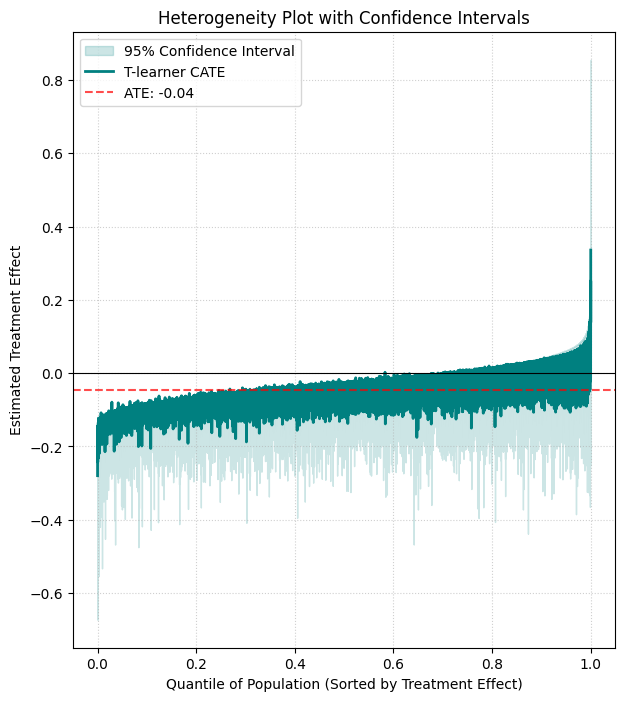

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sort everything based on the order of the original point estimates
# This ensures the CI "follows" the curve correctly
sort_idx = np.argsort(te_upper.flatten())
sorted_effects = T_te.flatten()[sort_idx]
sorted_lower = te_lower[sort_idx]
sorted_upper = te_upper[sort_idx]

# 2. Create x-axis
quantiles = np.linspace(0, 1, len(sorted_effects))

plt.figure(figsize=(7, 8))

# 3. Plot the Confidence Interval (Shaded Area)
plt.fill_between(quantiles, sorted_lower, sorted_upper, 
                 color='teal', alpha=0.2, label='95% Confidence Interval')

# 4. Plot the main CATE line
plt.plot(quantiles, sorted_effects, color='teal', linewidth=2, label='T-learner CATE')

# 5. Aesthetics and ATE
ate = np.mean(T_te)
plt.axhline(y=ate, color='red', linestyle='--', alpha=0.7, label=f'ATE: {ate:.2f}')
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel('Quantile of Population (Sorted by Treatment Effect)')
plt.ylabel('Estimated Treatment Effect')
plt.title('Heterogeneity Plot with Confidence Intervals')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Plot of effects for different subgroups

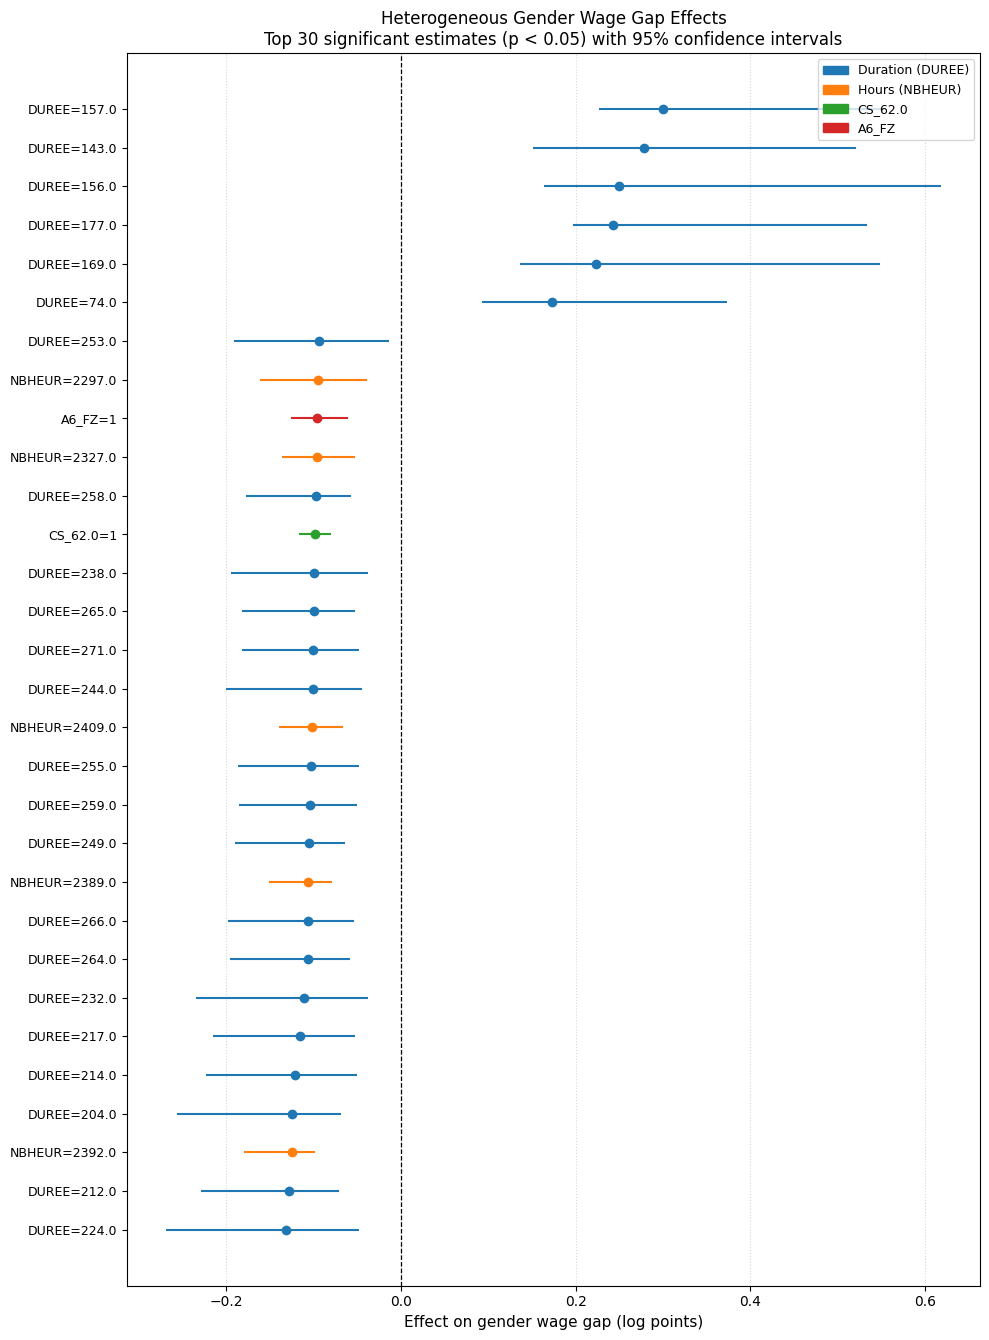

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm

TOP_N = 30

# --- Human-readable labels for each variable ---
var_labels = {
    "A6":        "Sector (A6)",
    "CS":        "Occupation (CS)",
    "REGR":      "Region (REGR)",
    "CONT_TRAV": "Contract (CONT_TRAV)",
    "AGE":       "Age",
    "AGE1":      "Age",
    "DUREE":     "Duration (DUREE)",
    "NBHEUR":    "Hours (NBHEUR)",
}

rows = []
for col in X.columns:
    for val in X[col].unique():
        mask = X[col] == val
        effects_leaf = T_te[mask]
        lower_leaf   = te_lower[mask]
        upper_leaf   = te_upper[mask]
        mean_effect = effects_leaf.mean()
        mean_lower  = lower_leaf.mean()
        mean_upper  = upper_leaf.mean()
        stderr      = (mean_upper - mean_lower) / (2 * 1.96)
        pval        = 2 * norm.sf(np.abs(mean_effect / stderr)) if stderr > 0 else 1.0
        label = f"{col}={val}"
        label = label.replace("C(", "").replace(")", "").replace("[T.", "=").replace("]", "")
        rows.append({
            "label":    label,
            "variable": col,          # raw column name, used for color grouping
            "effect":   mean_effect,
            "lower":    mean_lower,
            "upper":    mean_upper,
            "stderr":   stderr,
            "p_value":  pval,
            "n":        mask.sum()
        })

results = pd.DataFrame(rows)

# Keep significant rows, take top 30 by absolute effect, sort for plot
sig = (results[results["p_value"] < 0.05]
       .assign(abs_effect=lambda df: df["effect"].abs())
       .nlargest(TOP_N, "abs_effect")
       .drop(columns="abs_effect")
       .sort_values("effect"))

# --- Color palette: one color per unique VARIABLE (not per value) ---
unique_vars = sig["variable"].unique()
palette     = plt.cm.tab10.colors
color_map   = {var: palette[i % len(palette)] for i, var in enumerate(unique_vars)}

# --- Forest plot ---
fig, ax = plt.subplots(figsize=(10, max(6, len(sig) * 0.45)))
y_pos = np.arange(len(sig))

for i, (_, row) in enumerate(sig.iterrows()):
    col_color = color_map[row["variable"]]
    xerr_lo   = max(row["effect"] - row["lower"], 0)
    xerr_hi   = max(row["upper"] - row["effect"], 0)
    ax.errorbar(
        row["effect"], i,
        xerr=[[xerr_lo], [xerr_hi]],
        fmt='o', color=col_color,
        ecolor=col_color, elinewidth=1.5,
        capsize=0, markersize=6
    )

ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(sig["label"].values, fontsize=9)
ax.set_xlabel("Effect on gender wage gap (log points)", fontsize=11)
ax.set_title(
    f"Heterogeneous Gender Wage Gap Effects\nTop {TOP_N} significant estimates (p < 0.05) with 95% confidence intervals",
    fontsize=12
)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# --- Legend: one patch per variable, using human-readable labels ---
legend_patches = [
    mpatches.Patch(color=color_map[var], label=var_labels.get(var, var))
    for var in unique_vars
]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.show()

## Feature importance : contribution of each control variable to the gender wage gap

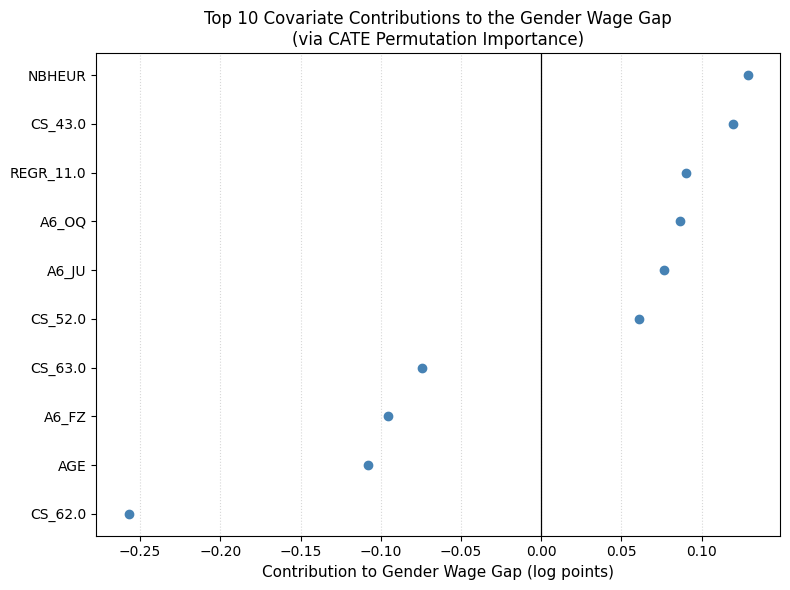

In [13]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingRegressor

TOP_N = 10  # adjust as needed

# --- Step 1: Train a "CATE explainer" model ---
cate_explainer = GradientBoostingRegressor(n_estimators=100, max_depth=6)
cate_explainer.fit(X, T_te.flatten())

# --- Step 2: Permutation importance ---
perm_imp = permutation_importance(
    cate_explainer, X, T_te.flatten(),
    n_repeats=30, random_state=42, scoring='r2'
)

importance_mean = perm_imp.importances_mean
importance_std  = perm_imp.importances_std

# --- Step 3: Build a signed importance ---
correlations = np.array([
    np.corrcoef(X.iloc[:, i], T_te.flatten())[0, 1]
    if X.iloc[:, i].std() > 0 else 0.0
    for i in range(X.shape[1])
])
signed_importance = importance_mean * np.sign(correlations)

# --- Step 4: Keep top N by absolute signed importance ---
top_idx = np.argsort(np.abs(signed_importance))[-TOP_N:]

feat_names   = np.array(X.columns)[top_idx]
feat_effects = signed_importance[top_idx]
feat_errors  = importance_std[top_idx]

# Sort low → high for plot readability
sort_idx     = np.argsort(feat_effects)
feat_names   = feat_names[sort_idx]
feat_effects = feat_effects[sort_idx]
feat_errors  = feat_errors[sort_idx]

# --- Step 5: Forest plot ---
fig, ax = plt.subplots(figsize=(8, max(6, len(feat_names) * 0.4)))

y_pos = np.arange(len(feat_names))

ax.errorbar(
    feat_effects, y_pos,
    xerr=feat_errors,
    fmt='o', color='steelblue',
    ecolor='steelblue', elinewidth=1.5,
    capsize=0, markersize=6
)

ax.axvline(0, color='black', linewidth=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names, fontsize=10)
ax.set_xlabel('Contribution to Gender Wage Gap (log points)', fontsize=11)
ax.set_title(f'Top {TOP_N} Covariate Contributions to the Gender Wage Gap\n(via CATE Permutation Importance)', fontsize=12)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()